In [1]:
############################ Adapted / Generated from PyTorch / torchvision documentation ############################

import random
import torch
from collections import Counter
from torch.utils.data import DataLoader, Subset
from torchvision import datasets
from torchvision.transforms import v2

In [2]:
############################ Coded by CHONG JIAN YI ############################
# Set Random Seed

random.seed(42)
torch.manual_seed(42);

In [3]:
############################ Coded by CHONG JIAN YI ############################
# Load Dataset 

data_dir = "/kaggle/input/datasets/sumn2u/garbage-classification-v2/standardized_384"

base_dataset = datasets.ImageFolder(root=data_dir)

class_names = base_dataset.classes
num_classes = len(class_names)

print("Total images:", len(base_dataset))
print("Classes:", class_names)

Total images: 12259
Classes: ['battery', 'biological', 'cardboard', 'clothes', 'glass', 'metal', 'paper', 'plastic', 'shoes', 'trash']


In [4]:
############################ Coded by CHONG JIAN YI ############################
# Class Distribution Analysis

label_counts = Counter(base_dataset.targets)

print("Images per class:")
for class_idx, count in sorted(label_counts.items()):
    print(f"{class_names[class_idx]}: {count}")

Images per class:
battery: 756
biological: 699
cardboard: 1411
clothes: 1892
glass: 1736
metal: 930
paper: 1336
plastic: 1597
shoes: 1449
trash: 453


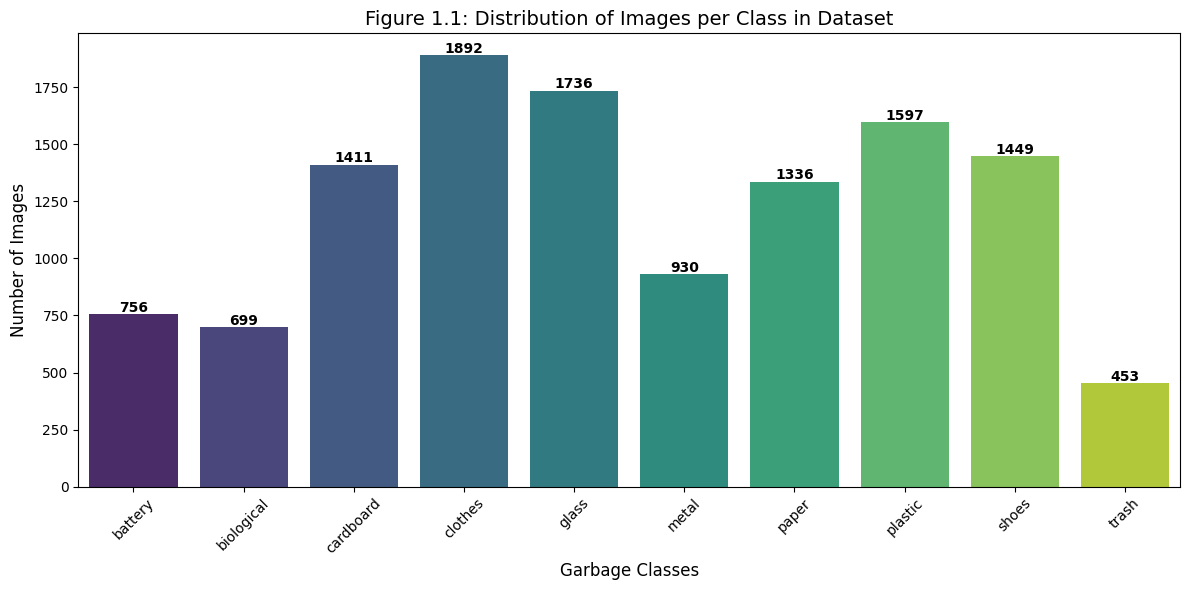

In [5]:
############################ Coded by CHONG JIAN YI ############################
# Visualizing Class Distribution
import matplotlib.pyplot as plt
import seaborn as sns

# Convert the label_counts to lists for plotting
classes = [class_names[i] for i in sorted(label_counts.keys())]
counts = [label_counts[i] for i in sorted(label_counts.keys())]

plt.figure(figsize=(12, 6))
ax = sns.barplot(x=classes, y=counts, hue=classes, palette="viridis", legend=False)

# Adding labels and title
plt.xlabel("Garbage Classes", fontsize=12)
plt.ylabel("Number of Images", fontsize=12)
plt.title("Figure 1.1: Distribution of Images per Class in Dataset", fontsize=14)
plt.xticks(rotation=45)

# Adding the count numbers on top of each bar
for i, v in enumerate(counts):
    ax.text(i, v + 10, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [6]:
############################ Coded by CHONG JIAN YI, Adapted / Generated from Lab 05 & Lab 06 (PyTorch transforms) ############################
# Define Data Transforms for training set

train_transform = v2.Compose([
    v2.ToImage(),
    v2.Resize((224, 224)),
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomRotation(degrees=10),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406],
                 std=[0.229, 0.224, 0.225]),
])


In [7]:
############################ Coded by CHONG JIAN YI, Adapted / Generated from Lab 05 & Lab 06 (PyTorch transforms) ############################
# Define Data Transforms for validation and testing set

eval_transform = v2.Compose([
    v2.ToImage(),
    v2.Resize((224, 224)),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406],
                 std=[0.229, 0.224, 0.225]),
])

In [8]:
############################ Coded by CHONG JIAN YI ############################
# Split Dataset (Stratified)

from sklearn.model_selection import train_test_split

num_samples = len(base_dataset)
indices = list(range(num_samples))

# Extract the labels (targets) from the dataset to use for stratification
targets = base_dataset.targets

# First split: Separate out 70% for Training, leaving 30% for Temp (Val + Test)
train_indices, temp_indices, _, temp_targets = train_test_split(
    indices, 
    targets, 
    test_size=0.30, 
    stratify=targets, 
    random_state=42 # Seed for reproducibility
)

# Second split: Divide the 30% Temp evenly into 15% Val and 15% Test
val_indices, test_indices, _, _ = train_test_split(
    temp_indices, 
    temp_targets,
    test_size=0.50, 
    stratify=temp_targets, 
    random_state=42
)

In [9]:
############################ Coded by CHONG JIAN YI ############################
# Create Dataset Subsets

train_dataset_full = datasets.ImageFolder(root=data_dir, transform=train_transform)
val_dataset_full   = datasets.ImageFolder(root=data_dir, transform=eval_transform)
test_dataset_full  = datasets.ImageFolder(root=data_dir, transform=eval_transform)

train_dataset = Subset(train_dataset_full, train_indices)
val_dataset   = Subset(val_dataset_full, val_indices)
test_dataset  = Subset(test_dataset_full, test_indices)

print("Train size:", len(train_dataset))
print("Validation size:", len(val_dataset))
print("Test size:", len(test_dataset))

Train size: 8581
Validation size: 1839
Test size: 1839


In [10]:
############################ Coded by Chong Jian Yi ############################
# Create DataLoaders with WeightedRandomSampler to fix Class Imbalance

from torch.utils.data import WeightedRandomSampler, DataLoader
import numpy as np

# 1. Get the targets specifically for the 70% training set
train_targets = [base_dataset.targets[i] for i in train_indices]

# 2. Calculate the weights for each class (Inverse frequency)
class_counts = np.bincount(train_targets)
class_weights = 1.0 / class_counts

# 3. Assign the correct weight to every individual sample in the training set
sample_weights = [class_weights[t] for t in train_targets]

# 4. Create the Sampler
sampler = WeightedRandomSampler(
    weights=sample_weights, 
    num_samples=len(sample_weights), 
    replacement=True
)

# 5. Create DataLoaders 
train_loader = DataLoader(train_dataset, batch_size=32, sampler=sampler)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("DataLoaders created successfully with WeightedRandomSampler.")

DataLoaders created successfully with WeightedRandomSampler.


In [11]:
############################ Coded by CHONG JIAN YI ############################
# Sanity Check

images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("First 10 labels:", labels[:10])

print("\nClass to index mapping:")
print(train_dataset_full.class_to_idx)

Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])
First 10 labels: tensor([2, 8, 8, 2, 6, 2, 3, 6, 7, 1])

Class to index mapping:
{'battery': 0, 'biological': 1, 'cardboard': 2, 'clothes': 3, 'glass': 4, 'metal': 5, 'paper': 6, 'plastic': 7, 'shoes': 8, 'trash': 9}


Handover summary for next member:
- Dataset: Garbage Classification V2
- Total images: 12259
- Classes: 10
- Class names: ['battery', 'biological', 'cardboard', 'clothes', 'glass', 'metal', 'paper', 'plastic', 'shoes', 'trash']
- Split: 70% train / 15% validation / 15% test
- Train transform: resize to 224x224, random horizontal flip, random rotation, normalization
- Validation/Test transform: resize to 224x224, normalization only
- Main outputs available:
train_loader
val_loader
test_loader
class_names
num_classes

In [12]:
############################ Coded by TEA KAI YANG, YIP SIEW HUI ############################
import time
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from torchvision.models import (
    resnet50, ResNet50_Weights,
    mobilenet_v2, MobileNet_V2_Weights,
    densenet121, DenseNet121_Weights,
    efficientnet_b0, EfficientNet_B0_Weights,
    convnext_tiny, ConvNeXt_Tiny_Weights
)

############################ Coded by TEA KAI YANG ############################
# Check if there is an available GPU. If not, use the CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Current computing device: {device}")

Current computing device: cuda


In [13]:
############################ Adapted / Generated from PyTorch documentation ############################
############################ Coded by YIP SIEW HUI, Create multiple models within a single function ############################

# Define Multiple Models
def get_model(model_name, num_classes):
    if model_name == "resnet50":
        # 1. Load ResNet50 with default pre-trained weight
        model = resnet50(weights=ResNet50_Weights.DEFAULT)

        # 2. Obtain the number of input features for the last layer (the fully connected layer fc) 
        num_ftrs = model.fc.in_features

        # 3. Replace the last layer so that the number of output nodes is equal to the number of your garbage categories
        model.fc = nn.Linear(num_ftrs, num_classes)

    
    elif model_name == "mobilenet_v2":
        # 1. Load the pre-trained MobileNetV2
        model = mobilenet_v2(weights=MobileNet_V2_Weights.DEFAULT)

        # 2. Modify the classification head (The classification head of MobileNetV2 is called classifier; we will modify the last layer)
        # The classifier [1] of MobileNetV2 is a Linear layer, and the input feature is 1280 
        num_ftrs_mobile = model.classifier[1].in_features
        
        model.classifier[1] = nn.Linear(num_ftrs_mobile, num_classes)

    
    elif model_name == "densenet121":
        model = densenet121(weights=DenseNet121_Weights.DEFAULT)
        model.classifier = nn.Linear(model.classifier.in_features, num_classes)

    
    elif model_name == "efficientnet_b0":
        model = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)

    elif model_name == "convnext_tiny":
        model = convnext_tiny(weights=ConvNeXt_Tiny_Weights.DEFAULT)

        # ConvNeXt uses classifier = Sequential([LayerNorm, Linear])
        in_features = model.classifier[2].in_features
        model.classifier[2] = nn.Linear(in_features, num_classes)
    
    else:
        raise ValueError(f"Model {model_name} not supported")

    
    return model

In [14]:
############################ Coded by TEA KAI YANG, Adapted / Generated from Lab sessions ############################
############################ Coded by YIP SIEW HUI, Refactor into a reuseable training function  ############################

# Create Generic Training Function
def train_model(model, train_loader, val_loader, criterion, optimizer, device, num_epochs, save_path):

    best_val_acc = 0.0
    
    print("🚀 Starting Training Process...")

    for epoch in range(num_epochs):
        epoch_start_time = time.time()
        
        # --- Training Phase ---
        model.train()
        running_loss = 0.0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * images.size(0)
        
        epoch_train_loss = running_loss / len(train_loader.dataset)
        
        # --- Validation Phase ---
        model.eval()
        val_loss = 0.0
        correct_preds = 0
        
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                
                outputs = model(images)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item() * images.size(0)
                _, preds = torch.max(outputs, 1)
                correct_preds += torch.sum(preds == labels.data)
        
        epoch_val_loss = val_loss / len(val_loader.dataset)
        epoch_val_acc = correct_preds.double() / len(val_loader.dataset)
        
        elapsed = time.time() - epoch_start_time
        
        print(f"Epoch {epoch+1}/{num_epochs} - Time: {elapsed:.0f}s")
        print(f"Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f}")
        
        # --- Save Best Model ---
        if epoch_val_acc > best_val_acc:
            best_val_acc = epoch_val_acc
            torch.save(model.state_dict(), save_path)
            print(f"⭐ --> Best model saved to {save_path}")
        
        print("-" * 40)
    
    print(f"✅ Training complete. Best Val Acc: {best_val_acc:.4f}")
    return best_val_acc

In [15]:
############################ Coded by YIP SIEW HUI, Overall ############################
# Train Multiple Models in Loop
model_list = ["resnet50", "mobilenet_v2", "densenet121", "efficientnet_b0", "convnext_tiny"]
# model_list = ["resnet50", "mobilenet_v2"]

for name in model_list:
    print(f"\n🚀 Training {name}...\n")

    num_epochs = 5

    # Move model to the GPU
    model = get_model(name, num_classes).to(device)

    ############################ Coded by TEA KAI YANG ############################
    # 1. Loss Function: Cross-entropy loss for multi-classification tasks
    criterion = nn.CrossEntropyLoss()

    # 2. Optimizer: Responsible for updating the model's weights. The learning rate is set to 0.001.
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    ###############################################################################
    
    save_path = f"{name}_best.pth"
    
    best_acc = train_model(
        model,
        train_loader,
        val_loader,
        criterion,
        optimizer,
        device,
        num_epochs,
        save_path=save_path
    )
    
    print(f"✅ Finished training {name} | The model file {save_path} is ready.")


🚀 Training resnet50...

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 177MB/s] 


🚀 Starting Training Process...
Epoch 1/5 - Time: 182s
Train Loss: 0.7347 | Val Loss: 0.5881 | Val Acc: 0.7977
⭐ --> Best model saved to resnet50_best.pth
----------------------------------------
Epoch 2/5 - Time: 145s
Train Loss: 0.4439 | Val Loss: 0.6010 | Val Acc: 0.8265
⭐ --> Best model saved to resnet50_best.pth
----------------------------------------
Epoch 3/5 - Time: 139s
Train Loss: 0.3339 | Val Loss: 0.6169 | Val Acc: 0.8200
----------------------------------------
Epoch 4/5 - Time: 135s
Train Loss: 0.2901 | Val Loss: 0.5071 | Val Acc: 0.8592
⭐ --> Best model saved to resnet50_best.pth
----------------------------------------
Epoch 5/5 - Time: 133s
Train Loss: 0.2484 | Val Loss: 0.4778 | Val Acc: 0.8733
⭐ --> Best model saved to resnet50_best.pth
----------------------------------------
✅ Training complete. Best Val Acc: 0.8733
✅ Finished training resnet50 | The model file resnet50_best.pth is ready.

🚀 Training mobilenet_v2...

Downloading: "https://download.pytorch.org/model

100%|██████████| 13.6M/13.6M [00:00<00:00, 116MB/s] 


🚀 Starting Training Process...
Epoch 1/5 - Time: 78s
Train Loss: 0.6013 | Val Loss: 0.4620 | Val Acc: 0.8564
⭐ --> Best model saved to mobilenet_v2_best.pth
----------------------------------------
Epoch 2/5 - Time: 77s
Train Loss: 0.3867 | Val Loss: 0.4437 | Val Acc: 0.8624
⭐ --> Best model saved to mobilenet_v2_best.pth
----------------------------------------
Epoch 3/5 - Time: 77s
Train Loss: 0.2952 | Val Loss: 0.3514 | Val Acc: 0.9010
⭐ --> Best model saved to mobilenet_v2_best.pth
----------------------------------------
Epoch 4/5 - Time: 77s
Train Loss: 0.2687 | Val Loss: 0.4009 | Val Acc: 0.8711
----------------------------------------
Epoch 5/5 - Time: 79s
Train Loss: 0.2236 | Val Loss: 0.3644 | Val Acc: 0.8999
----------------------------------------
✅ Training complete. Best Val Acc: 0.9010
✅ Finished training mobilenet_v2 | The model file mobilenet_v2_best.pth is ready.

🚀 Training densenet121...

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to

...

🚀 Starting Training Process...
Epoch 1/5 - Time: 136s
Train Loss: 0.8355 | Val Loss: 0.7481 | Val Acc: 0.7591
⭐ --> Best model saved to densenet121_best.pth
----------------------------------------
Epoch 2/5 - Time: 140s
Train Loss: 0.5170 | Val Loss: 0.6837 | Val Acc: 0.7700
⭐ --> Best model saved to densenet121_best.pth
----------------------------------------
Epoch 3/5 - Time: 136s
Train Loss: 0.4670 | Val Loss: 0.5893 | Val Acc: 0.8336
⭐ --> Best model saved to densenet121_best.pth
----------------------------------------
Epoch 4/5 - Time: 136s
Train Loss: 0.3853 | Val Loss: 0.4911 | Val Acc: 0.8510
⭐ --> Best model saved to densenet121_best.pth
----------------------------------------
Epoch 5/5 - Time: 143s
Train Loss: 0.3317 | Val Loss: 0.4935 | Val Acc: 0.8570
⭐ --> Best model saved to densenet121_best.pth
----------------------------------------
✅ Training complete. Best Val Acc: 0.8570
✅ Finished training densenet121 | The model file densenet121_best.pth is ready.

🚀 Training 

100%|██████████| 20.5M/20.5M [00:00<00:00, 148MB/s]


🚀 Starting Training Process...
Epoch 1/5 - Time: 90s
Train Loss: 0.6257 | Val Loss: 0.4767 | Val Acc: 0.8581
⭐ --> Best model saved to efficientnet_b0_best.pth
----------------------------------------
Epoch 2/5 - Time: 91s
Train Loss: 0.3599 | Val Loss: 0.4599 | Val Acc: 0.8641
⭐ --> Best model saved to efficientnet_b0_best.pth
----------------------------------------
Epoch 3/5 - Time: 91s
Train Loss: 0.2658 | Val Loss: 0.4688 | Val Acc: 0.8755
⭐ --> Best model saved to efficientnet_b0_best.pth
----------------------------------------
Epoch 4/5 - Time: 99s
Train Loss: 0.2169 | Val Loss: 0.4301 | Val Acc: 0.8934
⭐ --> Best model saved to efficientnet_b0_best.pth
----------------------------------------
Epoch 5/5 - Time: 91s
Train Loss: 0.1924 | Val Loss: 0.3601 | Val Acc: 0.9103
⭐ --> Best model saved to efficientnet_b0_best.pth
----------------------------------------
✅ Training complete. Best Val Acc: 0.9103
✅ Finished training efficientnet_b0 | The model file efficientnet_b0_best.pth

100%|██████████| 109M/109M [00:00<00:00, 201MB/s] 


🚀 Starting Training Process...
Epoch 1/5 - Time: 201s
Train Loss: 0.6715 | Val Loss: 0.6258 | Val Acc: 0.7896
⭐ --> Best model saved to convnext_tiny_best.pth
----------------------------------------
Epoch 2/5 - Time: 193s
Train Loss: 0.4301 | Val Loss: 0.4909 | Val Acc: 0.8385
⭐ --> Best model saved to convnext_tiny_best.pth
----------------------------------------
Epoch 3/5 - Time: 195s
Train Loss: 0.3489 | Val Loss: 0.5169 | Val Acc: 0.8374
----------------------------------------
Epoch 4/5 - Time: 195s
Train Loss: 0.3446 | Val Loss: 0.5209 | Val Acc: 0.8407
⭐ --> Best model saved to convnext_tiny_best.pth
----------------------------------------
Epoch 5/5 - Time: 199s
Train Loss: 0.2789 | Val Loss: 0.4271 | Val Acc: 0.8738
⭐ --> Best model saved to convnext_tiny_best.pth
----------------------------------------
✅ Training complete. Best Val Acc: 0.8738
✅ Finished training convnext_tiny | The model file convnext_tiny_best.pth is ready.


############################ Coded by TEA KAI YANG ############################

**Handover summary for Member 4 (Experiments & Evaluation):**

-> 10 output classes

-> Optimizer: Adam (lr=0.001)

-> Epochs trained: 5

<br>

**- I have trained TWO models for you to compare (for higher marks in the report!).**

Model 1 (Heavy & Accurate):
- Architecture: ResNet50 (Pre-Trained)
- Best Model Weights File: 'resnet50_garbage_best.pth'

Model 2 (Lightweight & Fast):
- Architecture: MobileNetV2 (Pre-Trained)
- Best Model Weights File: 'mobilenet_v2_garbage_best.pth'

**Next steps for Member 4:**
1. Load BOTH .pth files into their respective architecture models.
2. Use `test_loader` to evaluate the final accuracy for both.
3. Create a comparison table/chart (Accuracy vs. Model complexity) in the report! Generate confusion matrix and specific evaluation metrics.

**Handover summary:**

***What did I (Member 3) do:***

-> Define multiple models in 1 function, enable similar code reuse

-> Add 3 more architecture models for training
* DenseNet121
* EfficientNet-B0
* ConvNeXt-Tiny

***Notice:***

In the **last code block**, which handle training with load all five models, it will takes a very long time. 

If you **only** want to **load one model at one time**, you can modify:

model_list = ["resnet50", "mobilenet_v2", "densenet121", "efficientnet_b0", "convnext_tiny"]

into example:

model_list = ["resnet50"]

so that it contains only a single model name instead. Then copy, paste and modify at new code block. 


In [16]:
############################ Coded by [LEE CHENG JUN] ############################
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

model_names_short = {
    "resnet50": "ResNet-50", "mobilenet_v2": "MobileNetV2",
    "densenet121": "DenseNet-121", "efficientnet_b0": "EfficientNet-B0", "convnext_tiny": "ConvNeXt-Tiny"
}

def evaluate_model(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            _, preds = torch.max(model(images), 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return np.array(all_labels), np.array(all_preds)

results = {}
for name in model_list:
    model = get_model(name, num_classes).to(device)
    model.load_state_dict(torch.load(f"{name}_best.pth", map_location=device))
    y_true, y_pred = evaluate_model(model, test_loader, device)
    results[name] = {
        "accuracy":  accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, average='macro', zero_division=0),
        "recall":    recall_score(y_true, y_pred, average='macro', zero_division=0),
        "f1":        f1_score(y_true, y_pred, average='macro', zero_division=0),
        "y_true": y_true, "y_pred": y_pred
    }
    print(f"{model_names_short[name]}: Acc={results[name]['accuracy']:.4f} | Prec={results[name]['precision']:.4f} | Rec={results[name]['recall']:.4f} | F1={results[name]['f1']:.4f}")

# Summary table for report
best = max(results, key=lambda m: results[m]["accuracy"])
print("\n" + "=" * 75)
print(f"{'Model':<20} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1-Score':>10}")
print("=" * 75)
for name in model_list:
    r = results[name]
    marker = " <-- BEST" if name == best else ""
    print(f"{model_names_short[name]:<20} {r['accuracy']:>10.4f} {r['precision']:>10.4f} {r['recall']:>10.4f} {r['f1']:>10.4f}{marker}")
print("=" * 75)

# Detailed report for best model
print(f"\nDetailed Classification Report — {model_names_short[best]}:")
print(classification_report(results[best]["y_true"], results[best]["y_pred"], target_names=class_names, digits=4))

ResNet-50: Acc=0.8684 | Prec=0.8636 | Rec=0.8755 | F1=0.8637
MobileNetV2: Acc=0.8940 | Prec=0.8846 | Rec=0.8871 | F1=0.8836
DenseNet-121: Acc=0.8510 | Prec=0.8498 | Rec=0.8393 | F1=0.8397
EfficientNet-B0: Acc=0.9141 | Prec=0.8991 | Rec=0.9135 | F1=0.9047
ConvNeXt-Tiny: Acc=0.8700 | Prec=0.8618 | Rec=0.8565 | F1=0.8552

Model                  Accuracy  Precision     Recall   F1-Score
ResNet-50                0.8684     0.8636     0.8755     0.8637
MobileNetV2              0.8940     0.8846     0.8871     0.8836
DenseNet-121             0.8510     0.8498     0.8393     0.8397
EfficientNet-B0          0.9141     0.8991     0.9135     0.9047 <-- BEST
ConvNeXt-Tiny            0.8700     0.8618     0.8565     0.8552

Detailed Classification Report — EfficientNet-B0:
              precision    recall  f1-score   support

     battery     0.9550    0.9381    0.9464       113
  biological     0.9533    0.9714    0.9623       105
   cardboard     0.9104    0.9147    0.9125       211
     clothes

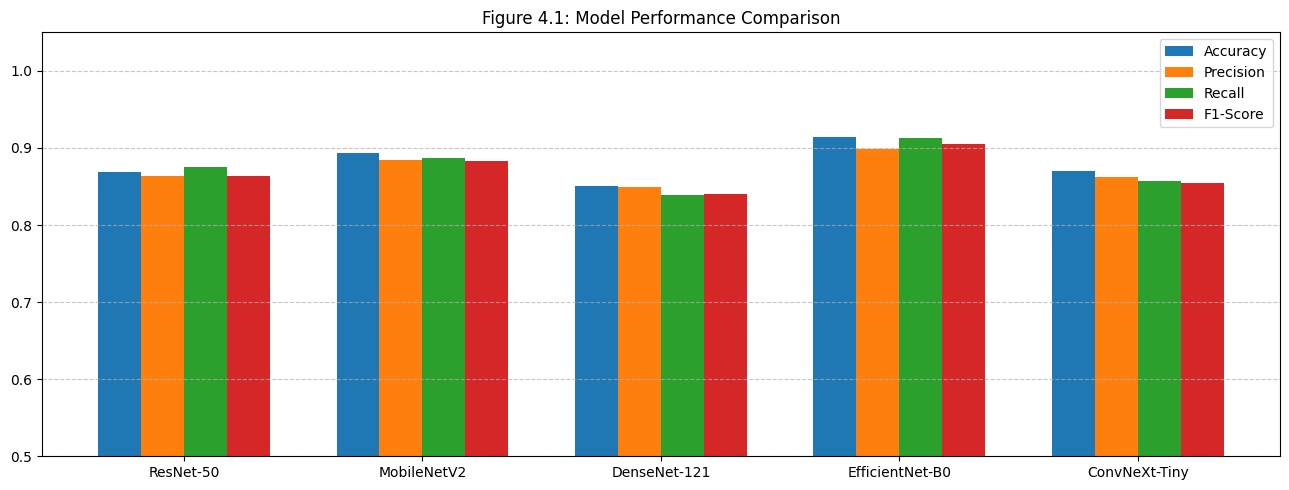

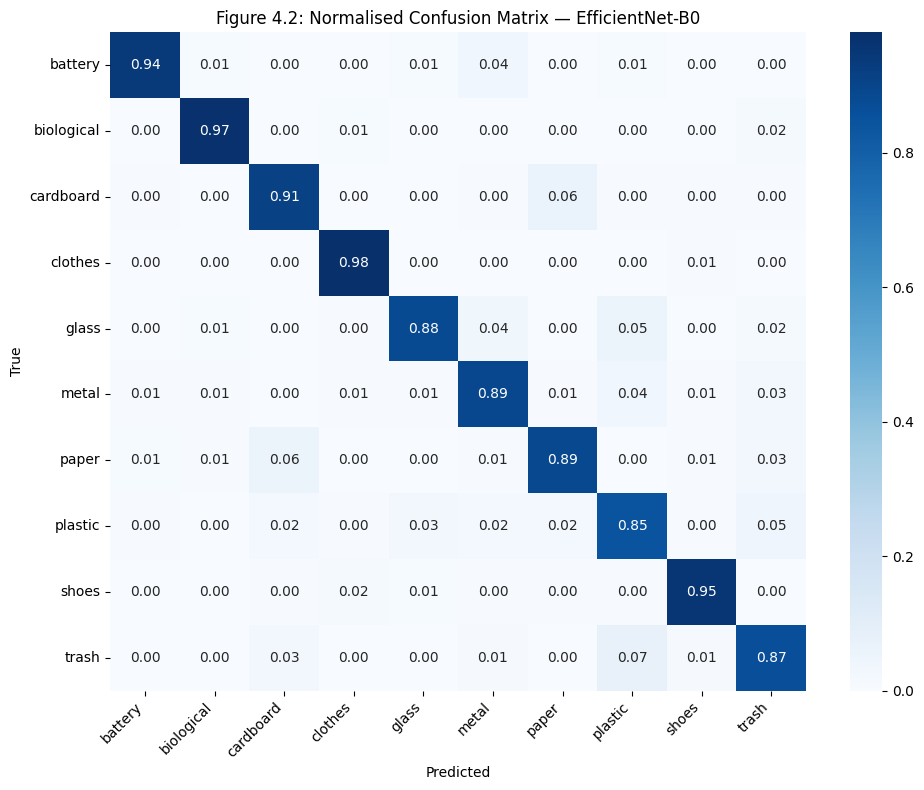

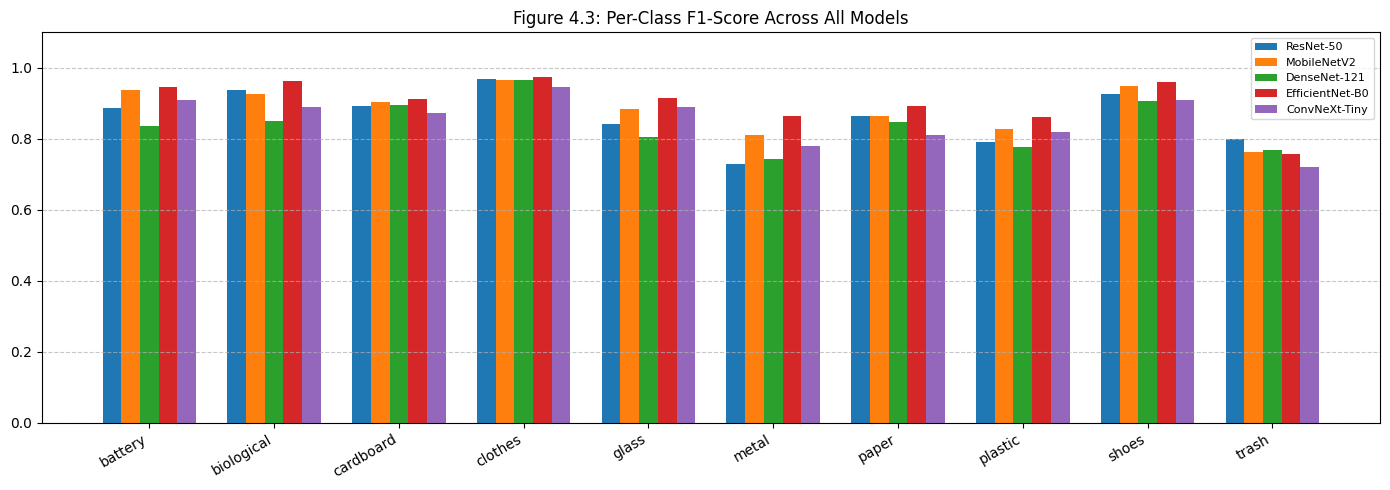

In [17]:
############################ Coded by [LEE CHENG JUN] ############################
metrics = ["accuracy","precision","recall","f1"]
metric_labels = ["Accuracy","Precision","Recall","F1-Score"]

# Fig 4.1 — Model Comparison
x_models = np.arange(len(model_list))
fig, ax = plt.subplots(figsize=(13,5))
for i,(m,ml) in enumerate(zip(metrics,metric_labels)):
    ax.bar(x_models + i*0.18, [results[n][m] for n in model_list], 0.18, label=ml)
ax.set_xticks(x_models+0.27)
ax.set_xticklabels([model_names_short[n] for n in model_list])
ax.set_ylim(0.5,1.05)
ax.set_title("Figure 4.1: Model Performance Comparison")
ax.legend(); ax.yaxis.grid(True,linestyle='--',alpha=0.7)
plt.tight_layout(); plt.savefig("fig4_1_model_comparison.png",dpi=150); plt.show()

# Fig 4.2 — Confusion Matrix (best model)
cm_norm = confusion_matrix(results[best]["y_true"], results[best]["y_pred"], normalize='true')
fig, ax = plt.subplots(figsize=(10,8))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title(f"Figure 4.2: Normalised Confusion Matrix — {model_names_short[best]}")
plt.xticks(rotation=45,ha='right')
plt.tight_layout(); plt.savefig("fig4_2_confusion_matrix.png",dpi=150); plt.show()

# Fig 4.3 — Per-class F1
x_classes = np.arange(len(class_names))
fig, ax = plt.subplots(figsize=(14,5))
for i,name in enumerate(model_list):
    ax.bar(x_classes + i*0.15,
           f1_score(results[name]["y_true"], results[name]["y_pred"], average=None, zero_division=0),
           0.15, label=model_names_short[name])
ax.set_xticks(x_classes+0.3)
ax.set_xticklabels(class_names, rotation=30, ha='right')
ax.set_ylim(0,1.1)
ax.set_title("Figure 4.3: Per-Class F1-Score Across All Models")
ax.legend(fontsize=8); ax.yaxis.grid(True,linestyle='--',alpha=0.7)
plt.tight_layout(); plt.savefig("fig4_3_perclass_f1.png",dpi=150); plt.show()

Hyperparameter Tuning: Learning Rate Comparison (EfficientNet-B0)

[LR = 0.01]
  Epoch 1/5 — Val Acc: 0.3632
  Epoch 2/5 — Val Acc: 0.4138
  Epoch 3/5 — Val Acc: 0.5503
  Epoch 4/5 — Val Acc: 0.5639
  Epoch 5/5 — Val Acc: 0.5557
  Test Acc: 0.5345 | F1: 0.5380

[LR = 0.001]
  Epoch 1/5 — Val Acc: 0.8380
  Epoch 2/5 — Val Acc: 0.8695
  Epoch 3/5 — Val Acc: 0.8967
  Epoch 4/5 — Val Acc: 0.8989
  Epoch 5/5 — Val Acc: 0.9016
  Test Acc: 0.9010 | F1: 0.8880

[LR = 0.0001]
  Epoch 1/5 — Val Acc: 0.9054
  Epoch 2/5 — Val Acc: 0.9337
  Epoch 3/5 — Val Acc: 0.9380
  Epoch 4/5 — Val Acc: 0.9309
  Epoch 5/5 — Val Acc: 0.9418
  Test Acc: 0.9462 | F1: 0.9400

LR           Best Val Acc     Test Acc         F1
0.01               0.5639       0.5345     0.5380
0.001              0.9016       0.9010     0.8880
0.0001             0.9418       0.9462     0.9400


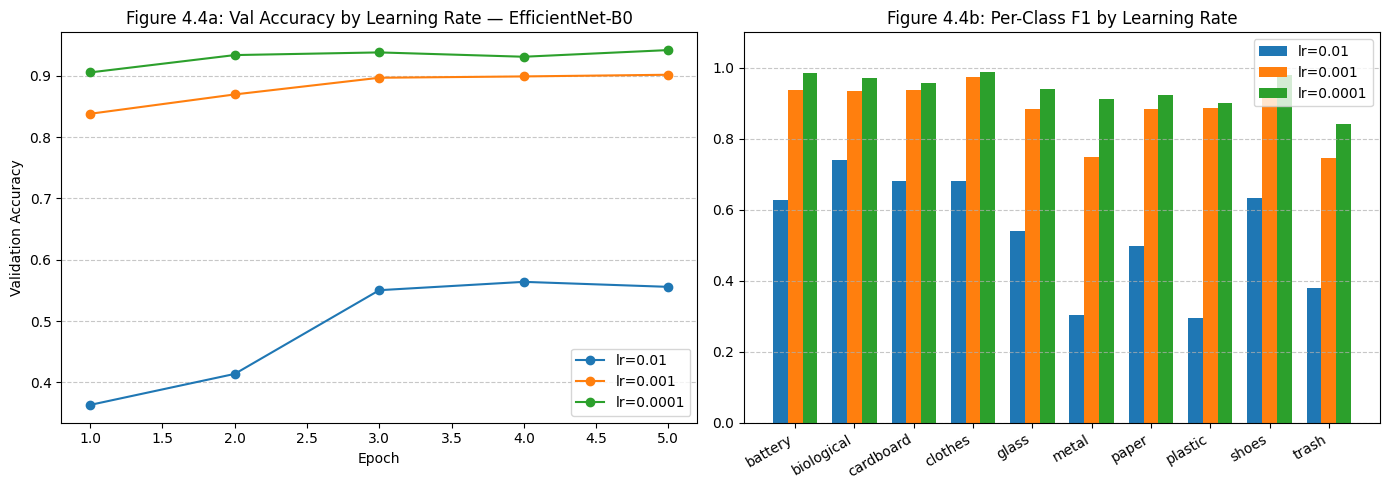

In [34]:
############################ Coded by [LEE CHENG JUN] ############################
# Hyperparameter Tuning: Learning Rate Comparison 

learning_rates = [0.01, 0.001, 0.0001]
lr_results = {}
epochs = 5

print(f"Hyperparameter Tuning: Learning Rate Comparison ({model_names_short[best]})\n")

for lr in learning_rates:
    print(f"[LR = {lr}]")
    model_lr = get_model(best, num_classes).to(device)
    opt = torch.optim.Adam(model_lr.parameters(), lr=lr)
    crit = torch.nn.CrossEntropyLoss()
    val_accs = []

    for ep in range(epochs):
        model_lr.train()
        for imgs, lbls in train_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            opt.zero_grad(); crit(model_lr(imgs), lbls).backward(); opt.step()

        model_lr.eval(); correct = total = 0
        with torch.no_grad():
            for imgs, lbls in val_loader:
                imgs, lbls = imgs.to(device), lbls.to(device)
                correct += (torch.max(model_lr(imgs),1)[1] == lbls).sum().item()
                total += lbls.size(0)
        acc = correct/total
        val_accs.append(acc)
        print(f"  Epoch {ep+1}/{epochs} — Val Acc: {acc:.4f}")

    y_true_lr, y_pred_lr = evaluate_model(model_lr, test_loader, device)
    lr_results[lr] = {
        "val_accs": val_accs,
        "test_acc": accuracy_score(y_true_lr, y_pred_lr),
        "f1": f1_score(y_true_lr, y_pred_lr, average='macro', zero_division=0),
        "f1_per_class": f1_score(y_true_lr, y_pred_lr, average=None, zero_division=0)
    }
    print(f"  Test Acc: {lr_results[lr]['test_acc']:.4f} | F1: {lr_results[lr]['f1']:.4f}\n")

# Summary table
print("=" * 55)
print(f"{'LR':<10} {'Best Val Acc':>14} {'Test Acc':>12} {'F1':>10}")
print("=" * 55)
for lr in learning_rates:
    r = lr_results[lr]
    print(f"{lr:<10} {max(r['val_accs']):>14.4f} {r['test_acc']:>12.4f} {r['f1']:>10.4f}")
print("=" * 55)

# Fig 4.4 — two subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: val acc curves
for lr in learning_rates:
    axes[0].plot(range(1, epochs+1), lr_results[lr]["val_accs"], 'o-', label=f'lr={lr}')
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Validation Accuracy")
axes[0].set_title(f"Figure 4.4a: Val Accuracy by Learning Rate — {model_names_short[best]}")
axes[0].legend(); axes[0].yaxis.grid(True, linestyle='--', alpha=0.7)

# Right: per-class F1
x_cls = np.arange(len(class_names))
width = 0.25
for i, lr in enumerate(learning_rates):
    axes[1].bar(x_cls + i*width, lr_results[lr]["f1_per_class"], width, label=f'lr={lr}')
axes[1].set_xticks(x_cls + width)
axes[1].set_xticklabels(class_names, rotation=30, ha='right')
axes[1].set_ylim(0, 1.1)
axes[1].set_title("Figure 4.4b: Per-Class F1 by Learning Rate")
axes[1].legend(); axes[1].yaxis.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig("fig4_4_ablation.png", dpi=150)
plt.show()

****Ablation Study****: With WeightedRandomSampler vs Without WeightedRandomSampler

In [35]:
############################ Coded by Chong Jian Yi ############################
# 1. Setup: Prepare the DataLoader WITHOUT WeightedRandomSampler

print(f"🚀 Data and Model ready for Ablation Study (No Sampler) on {model_names_short[best]}")

# use the original train_dataset (which HAS data augmentation)
# but create a new DataLoader WITHOUT the sampler, using standard shuffle=True
train_loader_no_sampler = DataLoader(train_dataset, batch_size=32, shuffle=True)

# Initialize the winning model architecture with optimized LR
model_no_sampler = get_model(best, num_classes).to(device)
opt_no_sampler = torch.optim.Adam(model_no_sampler.parameters(), lr=0.0001)
crit = torch.nn.CrossEntropyLoss()

🚀 Data and Model ready for Ablation Study (No Sampler) on EfficientNet-B0


In [36]:
############################ Coded by Chong Jian Yi ############################
# 2. Training the Ablated Model (No Sampler)

val_accs_no_sampler = []
print("🚀 Starting Training [Condition = Without Sampler]...")

for ep in range(epochs):
    model_no_sampler.train()
    for imgs, lbls in train_loader_no_sampler:
        imgs, lbls = imgs.to(device), lbls.to(device)
        opt_no_sampler.zero_grad(); crit(model_no_sampler(imgs), lbls).backward(); opt_no_sampler.step()

    model_no_sampler.eval(); correct = total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            correct += (torch.max(model_no_sampler(images),1)[1] == labels).sum().item()
            total += labels.size(0)
            
    acc = correct/total
    val_accs_no_sampler.append(acc)
    print(f"  Epoch {ep+1}/{epochs} — Val Acc: {acc:.4f}")

# Final Test Evaluation for this version
y_true_no_sampler, y_pred_no_sampler = evaluate_model(model_no_sampler, test_loader, device)
print(f"\n✅ Ablation Training Complete. Test Acc: {accuracy_score(y_true_no_sampler, y_pred_no_sampler):.4f}")

🚀 Starting Training [Condition = Without Sampler]...
  Epoch 1/5 — Val Acc: 0.9114
  Epoch 2/5 — Val Acc: 0.9364
  Epoch 3/5 — Val Acc: 0.9424
  Epoch 4/5 — Val Acc: 0.9413
  Epoch 5/5 — Val Acc: 0.9369

✅ Ablation Training Complete. Test Acc: 0.9347


Condition                   Best Val Acc     Test Acc   Macro F1
With Sampler                      0.9418       0.9462     0.9400
Without Sampler                   0.9424       0.9347     0.9239


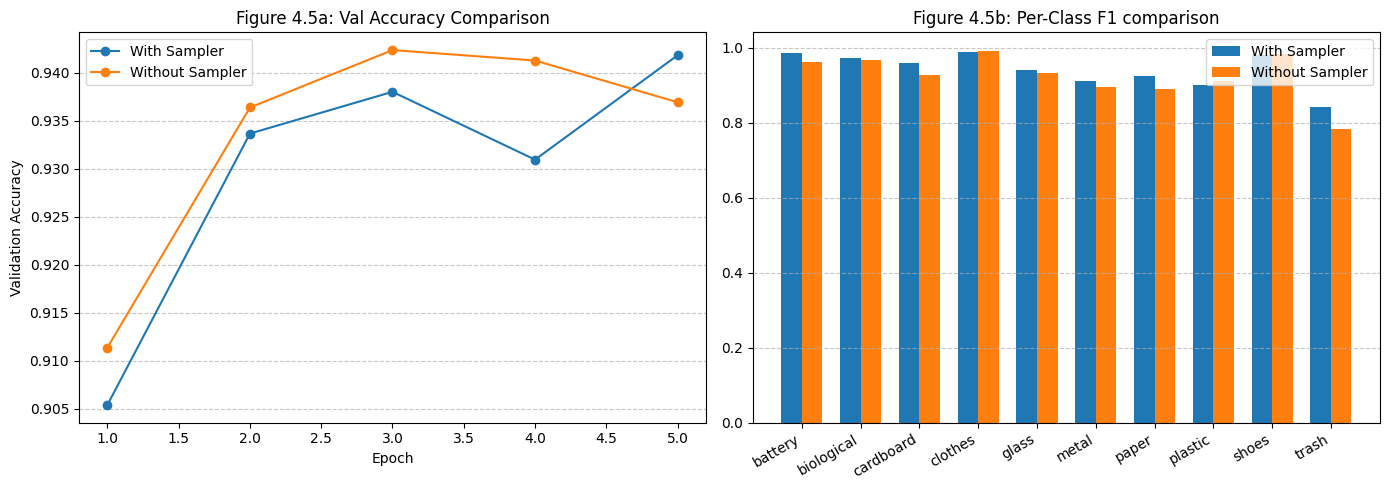

In [37]:
############################ Coded by Chong Jian Yi ############################
# 3. Visualization: Comparing With Sampler vs. Without Sampler

# Compile results
sampler_results = {
    "With Sampler": lr_results[0.0001],
    "Without Sampler": {
        "val_accs": val_accs_no_sampler,
        "test_acc": accuracy_score(y_true_no_sampler, y_pred_no_sampler),
        "f1": f1_score(y_true_no_sampler, y_pred_no_sampler, average='macro', zero_division=0),
        "f1_per_class": f1_score(y_true_no_sampler, y_pred_no_sampler, average=None, zero_division=0)
    }
}

# Print Summary Table
conditions = ["With Sampler", "Without Sampler"]
print("=" * 65)
print(f"{'Condition':<25} {'Best Val Acc':>14} {'Test Acc':>12} {'Macro F1':>10}")
print("=" * 65)
for cond in conditions:
    r = sampler_results[cond]
    print(f"{cond:<25} {max(r['val_accs']):>14.4f} {r['test_acc']:>12.4f} {r['f1']:>10.4f}")
print("=" * 65)

# Plot Figure 4.5: Comparison curves and bar charts
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 4.5a
for cond in conditions:
    axes[0].plot(range(1, epochs+1), sampler_results[cond]["val_accs"], 'o-', label=cond)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Validation Accuracy")
axes[0].set_title(f"Figure 4.5a: Val Accuracy Comparison")
axes[0].legend(); axes[0].yaxis.grid(True, linestyle='--', alpha=0.7)

# Plot 4.5b
x_cls = np.arange(len(class_names))
width = 0.35
for i, cond in enumerate(conditions):
    axes[1].bar(x_cls + i*width, sampler_results[cond]["f1_per_class"], width, label=cond)
axes[1].set_xticks(x_cls + width / 2)
axes[1].set_xticklabels(class_names, rotation=30, ha='right')
axes[1].set_title("Figure 4.5b: Per-Class F1 comparison")
axes[1].legend(); axes[1].yaxis.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout(); plt.savefig("fig4_5_sampler_ablation.png", dpi=150); plt.show()